# Credit Portfolio Risk Analytics — Python EDA

Цель этого ноутбука — провести первичный разведочный анализ данных кредитного портфеля, проверить качество данных и подготовить аналитическую витрину для расчёта ключевых метрик: approval rate, issue rate и DPD30+.

## 1. Загрузка библиотек и данных

На этом шаге импортируем необходимые библиотеки и загружаем четыре таблицы проекта:

- `clients` — данные клиентов;
- `loan_applications` — заявки на кредит;
- `loans` — выданные кредиты;
- `payments` — платежи по кредитам.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [ ]:
clients = pd.read_csv("../data/clients.csv", parse_dates=["birth_date", "registration_date"])
applications = pd.read_csv("../data/loan_applications.csv", parse_dates=["application_date"])
loans = pd.read_csv("../data/loans.csv", parse_dates=["issue_date"])
payments = pd.read_csv("../data/payments.csv", parse_dates=["payment_date"])

In [3]:
print("clients:", clients.shape)
print("applications:", applications.shape)
print("loans:", loans.shape)
print("payments:", payments.shape)

clients: (5000, 8)
applications: (14000, 6)
loans: (7634, 8)
payments: (81504, 5)


### Вывод

Данные успешно загружены.

В проекте используется 4 таблицы:

- `clients`: 5 000 клиентов;
- `loan_applications`: 14 000 заявок;
- `loans`: 7 634 выданных кредита;
- `payments`: 81 504 платежа.

Такой объём данных достаточен для анализа кредитной воронки, качества портфеля и просрочки DPD30+.

## 2. Проверка качества данных

Перед анализом метрик необходимо проверить качество данных:

- наличие дублей по ключевым идентификаторам;
- корректность связей между таблицами;
- отрицательные или нулевые финансовые значения;
- логическую корректность дат.

In [4]:
tables = {
    "clients": clients,
    "applications": applications,
    "loans": loans,
    "payments": payments
}

for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

clients: 5000 rows, 8 columns
applications: 14000 rows, 6 columns
loans: 7634 rows, 8 columns
payments: 81504 rows, 5 columns


### 2.1 Проверка дублей по ключам

In [5]:
dq_duplicates = {
    "clients duplicate client_id": clients["client_id"].duplicated().sum(),
    "applications duplicate application_id": applications["application_id"].duplicated().sum(),
    "loans duplicate loan_id": loans["loan_id"].duplicated().sum(),
    "payments duplicate payment_id": payments["payment_id"].duplicated().sum()
}

dq_duplicates

{'clients duplicate client_id': np.int64(0),
 'applications duplicate application_id': np.int64(0),
 'loans duplicate loan_id': np.int64(0),
 'payments duplicate payment_id': np.int64(0)}

Дубли по основным ключам не обнаружены. Это означает, что идентификаторы клиентов, заявок, кредитов и платежей уникальны.

### 2.2 Проверка связей между таблицами

In [6]:
dq_relations = {
    "applications without client": (~applications["client_id"].isin(clients["client_id"])).sum(),
    "loans without application": (~loans["application_id"].isin(applications["application_id"])).sum(),
    "loans without client": (~loans["client_id"].isin(clients["client_id"])).sum(),
    "payments without loan": (~payments["loan_id"].isin(loans["loan_id"])).sum()
}

dq_relations

{'applications without client': np.int64(0),
 'loans without application': np.int64(0),
 'loans without client': np.int64(0),
 'payments without loan': np.int64(0)}

Нарушений связей между таблицами не найдено:

- каждая заявка связана с существующим клиентом;
- каждый кредит связан с существующей заявкой и клиентом;
- каждый платёж связан с существующим кредитом.

Это подтверждает целостность данных между таблицами.

### 2.3 Проверка финансовых значений

In [7]:
dq_numeric = {
    "clients with income < 0": (clients["income"] < 0).sum(),
    "applications with requested_amount <= 0": (applications["requested_amount"] <= 0).sum(),
    "loans with loan_amount <= 0": (loans["loan_amount"] <= 0).sum(),
    "payments with paid_amount < 0": (payments["paid_amount"] < 0).sum(),
    "payments with overdue_days < 0": (payments["overdue_days"] < 0).sum()
}

dq_numeric

{'clients with income < 0': np.int64(0),
 'applications with requested_amount <= 0': np.int64(0),
 'loans with loan_amount <= 0': np.int64(0),
 'payments with paid_amount < 0': np.int64(0),
 'payments with overdue_days < 0': np.int64(0)}

Отрицательные или некорректные финансовые значения не обнаружены. Все суммы заявок, кредитов и платежей находятся в допустимых границах.

### 2.4 Проверка логики дат

In [8]:
loans_with_applications = loans.merge(
    applications[["application_id", "application_date"]],
    on="application_id",
    how="left"
)

payments_with_loans = payments.merge(
    loans[["loan_id", "issue_date"]],
    on="loan_id",
    how="left"
)

date_checks = {
    "loans issued before application": (
        loans_with_applications["issue_date"] < loans_with_applications["application_date"]
    ).sum(),
    "payments before loan issue": (
        payments_with_loans["payment_date"] < payments_with_loans["issue_date"]
    ).sum()
}

date_checks

{'loans issued before application': np.int64(0),
 'payments before loan issue': np.int64(0)}

Ошибок в логике дат не обнаружено:

- кредиты не выдавались раньше даты подачи заявки;
- платежи не происходили раньше даты выдачи кредита.

Данные можно использовать для дальнейшего анализа.

### Итог проверки качества данных

Критических проблем в данных не найдено:

- дубли по ключевым идентификаторам отсутствуют;
- связи между таблицами корректны;
- отрицательные значения в финансовых полях отсутствуют;
- логика дат не нарушена.

Датасет является консистентным и подходит для дальнейшего анализа кредитной воронки и просрочки DPD30+.

## 3. Аналитическая витрина



### 3.1 Агрегируем payments до уровня кредита


In [9]:
loan_dpd = (payments.groupby("loan_id", as_index = False).agg(
        max_overdue_days=("overdue_days", "max"),
        payments_count=("payment_id", "count"),
        total_paid_amount=("paid_amount", "sum")
    )
)
loan_dpd["is_dpd30"] = loan_dpd["max_overdue_days"] >=30


### 3.2 Обогащаем loans данными по платежам и DPD30


In [10]:
loans_enriched  = loans.merge(loan_dpd, on="loan_id", how="left")
loans_enriched.head()

,loan_id,application_id,client_id,issue_date,product_name,loan_amount,interest_rate,term_months,max_overdue_days,payments_count,total_paid_amount,is_dpd30
0,1,1,130,2026-02-19,Auto loan,"9,987,360.46",17.87,60,15.00,2.00,"285,588.18",False
1,2,2,2714,2025-12-14,Credit card,"1,720,776.20",32.22,36,15.00,4.00,"181,219.80",False
2,3,6,1456,2025-06-26,POS loan,"324,029.06",18.64,12,7.00,10.00,"236,920.33",False
3,4,7,448,2024-06-03,Micro loan,"276,033.06",31.54,6,7.00,6.00,"242,977.52",False
4,5,9,4851,2024-10-29,POS loan,"915,096.66",13.64,6,3.00,6.00,"650,446.47",False


### 3.3. Собираем финальную аналитическую витрину на уровне заявки


In [11]:
df = (
    applications
    .merge(
        clients,
        on="client_id",
        how="left"
    )
    .merge(
        loans_enriched.drop(columns=["client_id", "product_name"]),
        on="application_id",
        how="left"
    )
)

### 3.4 Добавляем аналитические флаги


In [12]:
df["is_approved"] = df["status"].eq("approved")
df["is_issued"] = df["loan_id"].notna()
df["is_dpd30"] = df["is_dpd30"].fillna(False)
df["application_month"] = df["application_date"].dt.to_period("M").dt.to_timestamp()

### 3.5 Проверяем, что merge не сломал уровень данных


In [13]:
print("applications rows:", applications.shape[0])
print("df rows:", df.shape[0])
print("duplicated application_id:", df["application_id"].duplicated().sum())
print("issued loans:", df["loan_id"].notna().sum())
print("loans rows:", loans.shape[0])

applications rows: 14000
df rows: 14000
duplicated application_id: 0
issued loans: 7634
loans rows: 7634


### Итоги витрины

Основная аналитическая витрина построена на уровне заявки: одна строка соответствует одной кредитной заявке.

Перед соединением с основной таблицей данные по платежам были агрегированы до уровня кредита. Это нужно, чтобы избежать задвоения заявок и кредитов, так как у одного кредита может быть несколько платежей.

В итоговую витрину добавлены ключевые аналитические признаки:

- `is_approved` — заявка была одобрена;
- `is_issued` — по заявке был выдан кредит;
- `is_dpd30` — по кредиту была просрочка 30+ дней;
- `application_month` — месяц подачи заявки.

## 4. Месячные метрики кредитной воронки

На этом шаге рассчитываем ключевые метрики по месяцам подачи заявки: количество заявок, одобрений, выдач, approval rate, issue rate и DPD30 rate.

In [ ]:
monthly_metrics = (
    df
    .groupby("application_month", as_index=False).agg(
        applications_count = ("application_id", "count"),
        approved_count = ("is_approved", "sum"),
        issued_count = ("is_issued", "sum"),
        dpd30_loans=("is_dpd30", "sum"),
        requested_amount=("requested_amount", "sum"),
        issued_amount=("loan_amount", "sum")
    ))
monthly_metrics["approval_rate"] = (monthly_metrics["approved_count"] / monthly_metrics["applications_count"])
monthly_metrics["issue_rate"] = (monthly_metrics["issued_count"] / monthly_metrics["approved_count"].replace(0, np.nan))
monthly_metrics["dpd30_rate"] = (monthly_metrics["dpd30_loans"] / monthly_metrics["issued_count"].replace(0, np.nan))
monthly_metrics

,application_month,applications_count,approved_count,issued_count,dpd30_loans,requested_amount,issued_amount,approval_rate,issue_rate,dpd30_rate
0,2024-01-01,507,324,276,26,"1,015,654,590.00","406,395,654.51",0.64,0.85,0.09
1,2024-02-01,466,293,260,23,"834,372,218.00","410,384,661.62",0.63,0.89,0.09
2,2024-03-01,540,344,297,22,"958,519,448.00","395,487,261.15",0.64,0.86,0.07
3,2024-04-01,516,338,300,31,"976,709,786.00","479,352,967.79",0.66,0.89,0.10
4,2024-05-01,480,314,260,26,"1,007,082,628.00","451,181,909.96",0.65,0.83,0.10
5,2024-06-01,516,332,281,22,"1,049,872,666.00","402,753,239.20",0.64,0.85,0.08
6,2024-07-01,506,333,286,28,"899,564,116.00","385,851,749.79",0.66,0.86,0.10
7,2024-08-01,518,322,269,28,"977,809,380.00","404,395,862.44",0.62,0.84,0.10
8,2024-09-01,484,291,250,24,"937,788,752.00","396,117,042.75",0.60,0.86,0.10
9,2024-10-01,502,322,286,31,"898,315,918.00","480,233,472.18",0.64,0.89,0.11


### Логика расчёта

Метрики рассчитаны на уровне месяца подачи заявки.

- `approval_rate` показывает долю одобренных заявок от всех заявок.
- `issue_rate` показывает долю выданных кредитов от одобренных заявок.
- `dpd30_rate` показывает долю кредитов с просрочкой 30+ дней от всех выданных кредитов.

Для защиты от деления на ноль используется замена нулевого знаменателя на `NaN`.

## 5. Визуальный анализ метрик

На этом этапе визуализируем ключевые метрики кредитной воронки и качества портфеля. Графики помогают увидеть динамику заявок, одобрений, выдач и просрочки DPD30+ по месяцам.

График 1. Количество заявок по месяцам

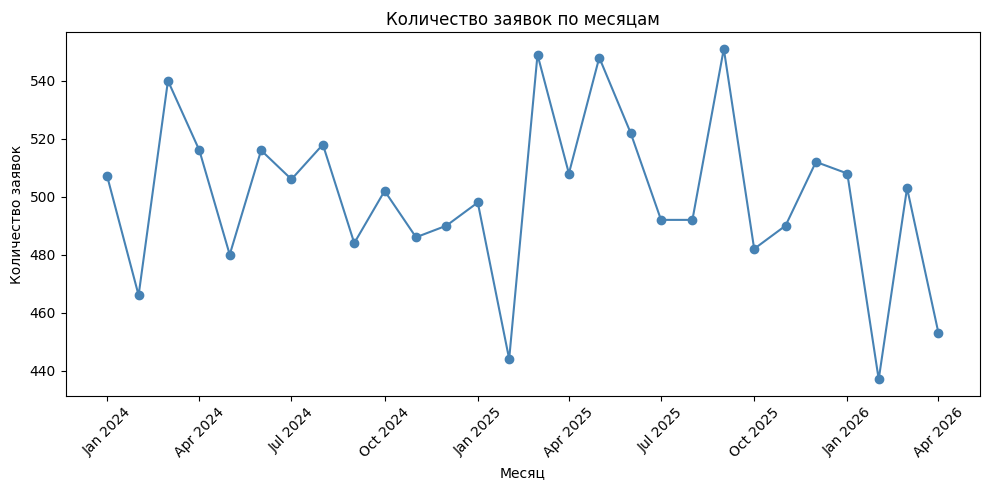

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    monthly_metrics["application_month"],
    monthly_metrics["applications_count"],
    marker="o", color = "steelblue")
ax.set_title("Количество заявок по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Количество заявок")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод

График показывает динамику количества кредитных заявок по месяцам.  
Количество заявок по месяцам колеблется примерно в диапазоне 430–550 заявок. Явного устойчивого роста или падения входящего потока не наблюдается, однако в отдельных месяцах видны локальные пики и просадки.
Наиболее заметные просадки наблюдаются в начале 2025 и 2026 года. Для дальнейшего анализа стоит проверить, связаны ли эти изменения с сезонностью, маркетинговой активностью или изменениями в кредитной политике.

График 2. Одобрения и выдачи по месяцам

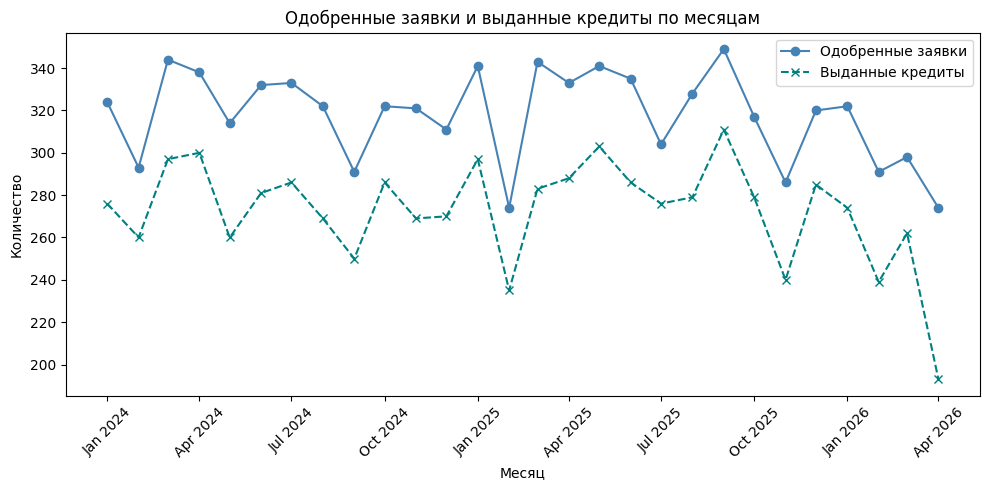

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_metrics["application_month"],
    monthly_metrics["approved_count"],
    marker="o",
    linestyle="-",
    label="Одобренные заявки", color = "steelblue")

ax.plot(
    monthly_metrics["application_month"],
    monthly_metrics["issued_count"],
    marker="x",
    linestyle="--",
    label="Выданные кредиты", color = "teal")

ax.set_title("Одобренные заявки и выданные кредиты по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Количество")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод

Количество выданных кредитов стабильно ниже количества одобренных заявок, что отражает естественный разрыв между этапами одобрения и фактической выдачи.

Динамика двух показателей в целом движется синхронно: месяцы с большим количеством одобрений обычно сопровождаются ростом выдач. Это говорит о том, что выдачи в основном зависят от объёма одобренных заявок.

В конце периода наблюдается заметное снижение количества выдач. Последний месяц может быть неполным, поэтому его стоит интерпретировать осторожно.

График 3. Approval rate по месяцам

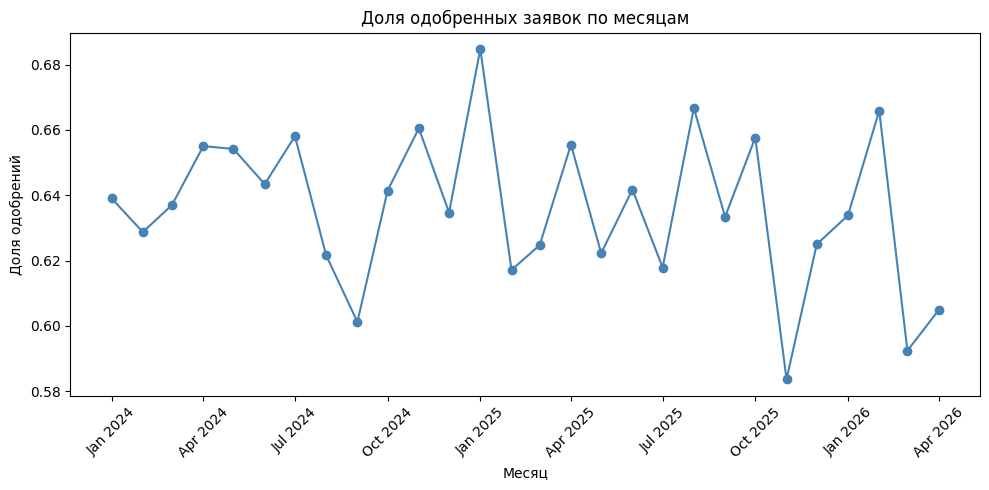

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    monthly_metrics["application_month"],
    monthly_metrics["approval_rate"],
    marker="o", color = "steelblue")
ax.set_title("Доля одобренных заявок по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Доля одобрений")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод

Approval rate показывает долю заявок, которые были одобрены. Снижение approval rate может указывать на ужесточение скоринговой политики, изменение качества входящего потока клиентов или рост доли рискованных заявок.

График 4. Issue rate по месяцам

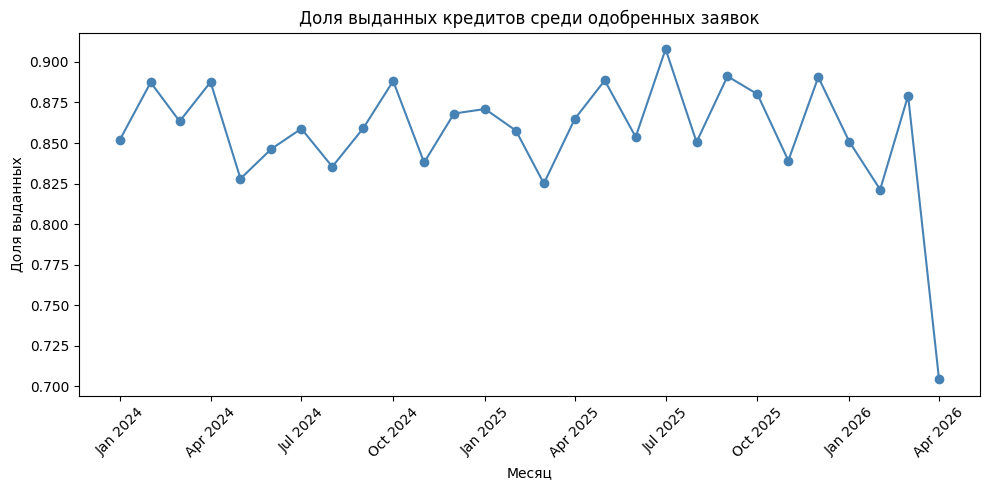

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    monthly_metrics["application_month"],
    monthly_metrics["issue_rate"],
    marker="o", color = "steelblue")
ax.set_title("Доля выданных кредитов среди одобренных заявок")
ax.set_xlabel("Месяц")
ax.set_ylabel("Доля выданных")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод

Issue rate по месяцам находится примерно в диапазоне 70–91%. Это означает, что большая часть одобренных заявок завершается фактической выдачей кредита.

В отдельные месяцы видны просадки issue rate, например ближе к концу периода. Это может быть связано с тем, что часть клиентов не доходит до получения кредита после одобрения, отказывается от условий или не проходит финальные этапы оформления.

Последний месяц может быть неполным, поэтому его значения стоит анализировать осторожно.

График 5. DPD30 rate по месяцам

Что показываем:
Долю кредитов с просрочкой 30+ дней среди выданных кредитов.

Зачем:
Это главный risk-график. Он показывает качество выдач.

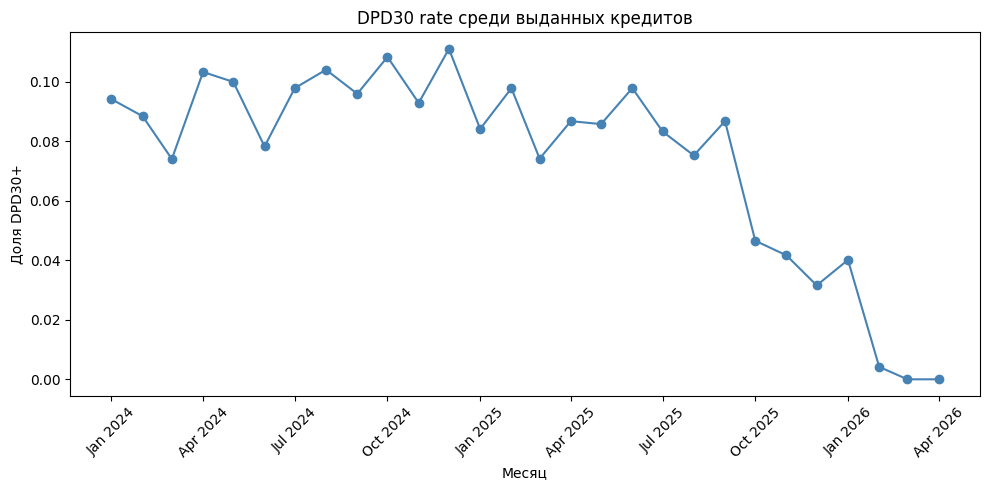

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    monthly_metrics["application_month"],
    monthly_metrics["dpd30_rate"],
    marker="o", color = "steelblue")
ax.set_title("DPD30 rate среди выданных кредитов")
ax.set_xlabel("Месяц")
ax.set_ylabel("Доля DPD30+")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод

DPD30 rate показывает долю выданных кредитов, по которым была зафиксирована просрочка 30+ дней.

В первой части периода показатель держится примерно на уровне 7–11%, что отражает стабильный уровень просрочки в портфеле. Ближе к концу периода DPD30 rate резко снижается почти до нуля.

Такое снижение следует интерпретировать осторожно: последние выдачи могут быть слишком свежими, и по ним ещё не прошло достаточно времени для формирования DPD30+. Для более корректной оценки качества портфеля дополнительно нужен vintage/MOB-анализ.

График 6. DPD30 rate по продуктам

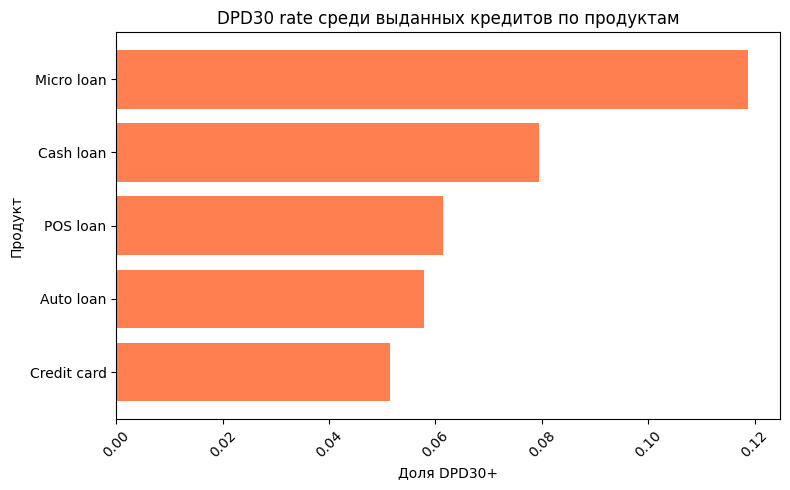

In [ ]:
dpd_per_product = df.groupby("product_name",as_index=False).agg(
        issued_count = ("is_issued", "sum"),
        dpd30_loans=("is_dpd30", "sum"),
    )
dpd_per_product["dpd30_rate"] = (dpd_per_product["dpd30_loans"] / dpd_per_product["issued_count"].replace(0, np.nan))
dpd_per_product = dpd_per_product.sort_values("dpd30_rate")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(dpd_per_product["product_name"], dpd_per_product["dpd30_rate"].values, color="coral")

ax.set_title("DPD30 rate среди выданных кредитов по продуктам")
ax.set_xlabel("Доля DPD30+")
ax.set_ylabel("Продукт")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод

DPD30 rate различается по кредитным продуктам. Самый высокий уровень просрочки 30+ наблюдается у `Micro loan`, что может указывать на более рискованный профиль клиентов или особенности условий этого продукта.

`Cash loan` также показывает повышенный уровень DPD30+ по сравнению с остальными продуктами. Для дальнейшего анализа стоит проверить кредитный скор, доход и тип занятости клиентов внутри этих продуктов.

График 7. DPD30 rate по credit score bucket

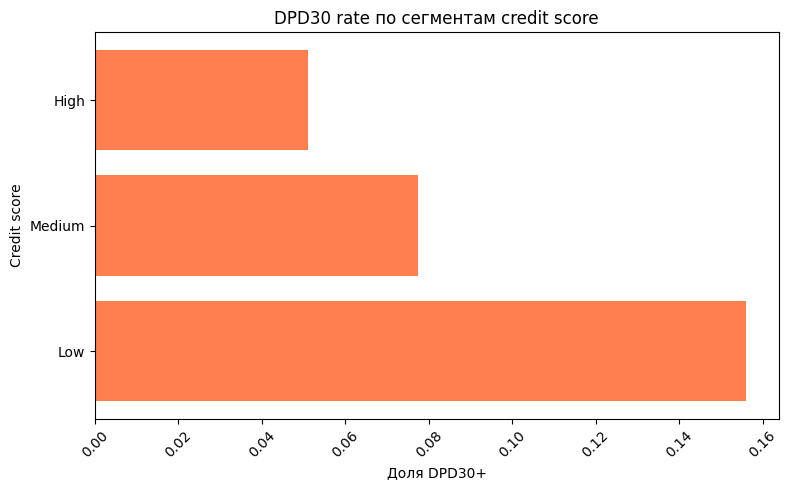

In [ ]:
df["score_bucket"] = pd.cut(
    df["credit_score"],
    bins=[0, 500, 750, 1000],
    labels=["Low", "Medium", "High"],
    include_lowest=True)

dpd_per_credit_score= df.groupby("score_bucket",as_index=False).agg(
        issued_count = ("is_issued", "sum"),
        dpd30_loans=("is_dpd30", "sum"),
    )
dpd_per_credit_score["dpd30_rate"] = (dpd_per_credit_score["dpd30_loans"] / dpd_per_credit_score["issued_count"].replace(0, np.nan))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(dpd_per_credit_score["score_bucket"], dpd_per_credit_score["dpd30_rate"].values, color="coral")

ax.set_title("DPD30 rate по сегментам credit score")
ax.set_xlabel("Доля DPD30+")
ax.set_ylabel("Credit score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод

Анализ DPD30 rate по сегментам `credit_score` показывает ожидаемую зависимость: сегмент `Low` имеет самый высокий уровень просрочки, а сегменты `Medium` и `High` — более низкий. Это подтверждает, что кредитный скор в датасете отражает риск-профиль клиента.

График 8. DPD30 rate по employment_type

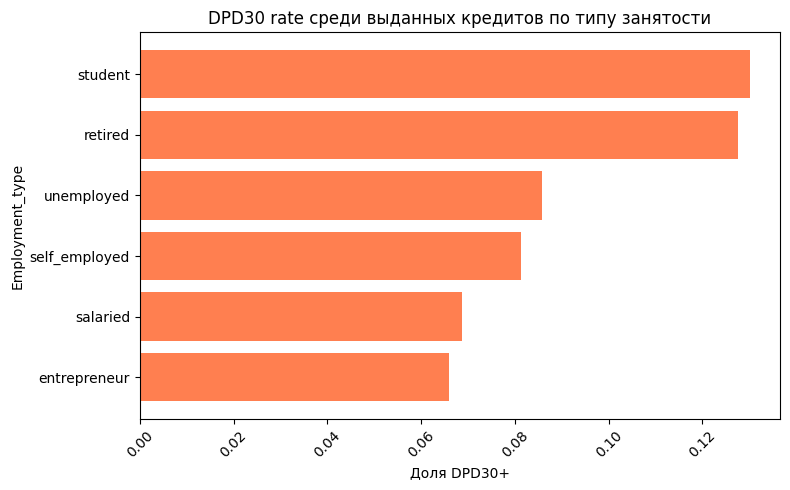

In [ ]:
dpd_per_employment= df.groupby("employment_type",as_index=False).agg(
        issued_count = ("is_issued", "sum"),
        dpd30_loans=("is_dpd30", "sum"),
    )
dpd_per_employment["dpd30_rate"] = (dpd_per_employment["dpd30_loans"] / dpd_per_employment["issued_count"].replace(0, np.nan))
dpd_per_employment = dpd_per_employment.sort_values("dpd30_rate")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(dpd_per_employment["employment_type"], dpd_per_employment["dpd30_rate"].values, color="coral")

ax.set_title("DPD30 rate среди выданных кредитов по типу занятости")
ax.set_xlabel("Доля DPD30+")
ax.set_ylabel("Employment_type")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод

DPD30 rate различается между группами клиентов по типу занятости. Наиболее высокий уровень просрочки 30+ наблюдается у клиентов со статусом `student` и `retired`.

Это может указывать на более высокий риск в группах с менее стабильным или ограниченным доходом. Для дальнейшего анализа стоит сравнить эти сегменты по среднему доходу, сумме кредита и кредитному скору.

## 6. Распределение клиентских признаков

### 6.1 Распределение credit_score

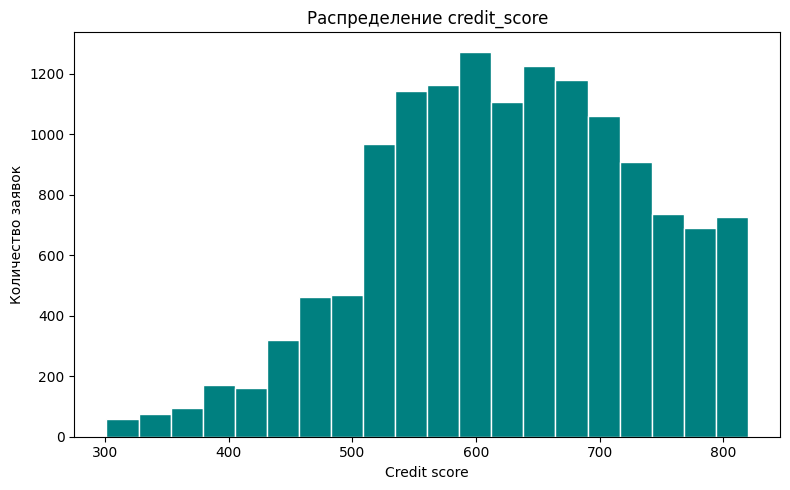

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["credit_score"], bins=20, color="teal", edgecolor="white")
ax.set_title("Распределение credit_score")
ax.set_xlabel("Credit score")
ax.set_ylabel("Количество заявок")
plt.tight_layout()
plt.show()

### Вывод

Распределение `credit_score` показывает, что основная часть заявок приходится на клиентов со средним и хорошим кредитным скором. Низкие значения score встречаются реже, но именно они важны для риск-анализа, так как ранее было видно, что сегмент `Low` имеет самый высокий DPD30 rate.

Этот график помогает объяснить структуру входящего потока заявок и связать её с дальнейшим анализом просрочки по скоринговым сегментам.

### 6.2 Распределение income

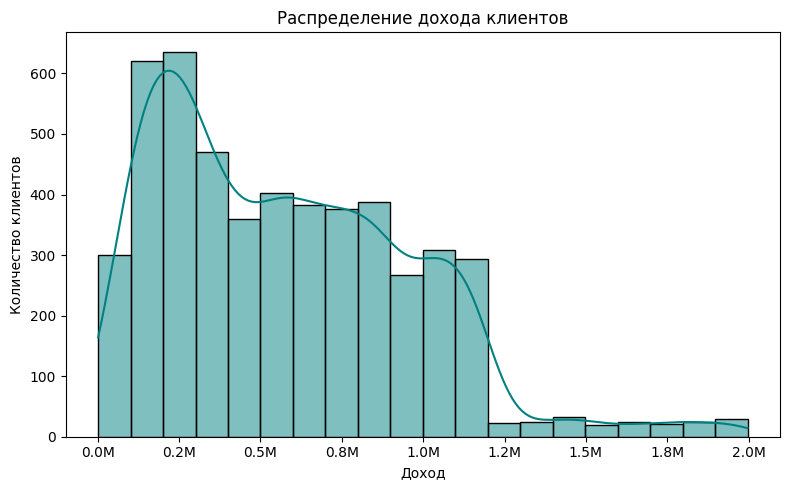

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=clients, x="income", bins=20, kde=True, ax=ax, color="teal")
ax.set_title("Распределение дохода клиентов")
ax.set_xlabel("Доход")
ax.set_ylabel("Количество клиентов")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M"))

plt.tight_layout()
plt.show()

### Вывод

Распределение `income` показывает, что основная часть клиентов имеет доход до примерно 1.2 млн. Также виден правый хвост распределения: небольшая часть клиентов имеет существенно более высокий доход.

Из-за таких высоких значений средний доход может быть выше типичного значения для большинства клиентов, поэтому для анализа клиентского профиля полезно дополнительно смотреть медиану.

In [78]:
clients["income"].agg(["mean", "median"])

mean     581,006.45
median   529,243.50
Name: income, dtype: float64

Средний доход выше медианного, что подтверждает наличие правого хвоста распределения: небольшая группа клиентов с высоким доходом повышает среднее значение.

### Вывод

Распределение `income` показывает, что основная часть клиентов имеет доход до примерно 1.2 млн. Также виден правый хвост распределения: небольшая часть клиентов имеет существенно более высокий доход.

Из-за таких высоких значений средний доход может быть выше типичного значения для большинства клиентов, поэтому для анализа клиентского профиля полезно дополнительно смотреть медиану.

## 7. Основные выводы

1. Количество кредитных заявок по месяцам относительно стабильно и в основном колеблется в диапазоне 430–550 заявок. Явного долгосрочного роста или падения входящего потока не наблюдается, однако в отдельных месяцах видны локальные пики и просадки.

2. Количество одобренных заявок и выданных кредитов движется примерно в одном направлении. Это показывает, что объём выдач в основном зависит от количества одобренных заявок. При этом выданных кредитов меньше, чем одобренных заявок, что отражает естественный разрыв между этапом одобрения и фактической выдачей.

3. Approval rate находится примерно в диапазоне 58–68%. Это означает, что в среднем около двух третей заявок получают одобрение. Колебания approval rate могут быть связаны с качеством входящего потока клиентов, сезонностью или изменениями в кредитной политике.

4. Issue rate в большинстве месяцев держится на достаточно высоком уровне — примерно 70–90%. Это означает, что большая часть одобренных заявок переходит в фактическую выдачу кредита. Просадки issue rate в отдельных месяцах могут быть связаны с отказом клиентов от кредита, финальными проверками или неполным последним периодом.

5. DPD30 rate среди выданных кредитов в первой части периода находится примерно на уровне 7–11%. Ближе к концу периода показатель снижается почти до нуля, но это нужно интерпретировать осторожно: последние кредиты могут быть слишком свежими, и по ним ещё не прошло достаточно времени для формирования просрочки 30+ дней.

6. Среди кредитных продуктов самый высокий DPD30 rate наблюдается у `Micro loan`, также повышенный уровень риска виден у `Cash loan`. Эти продукты требуют дополнительного анализа по скорингу, доходу, типу занятости клиентов и сумме кредита.

7. Анализ DPD30 rate по сегментам `credit_score` показывает ожидаемую зависимость: сегмент `Low` имеет самый высокий уровень просрочки, а сегмент `High` — более низкий. Это подтверждает, что кредитный скор в датасете отражает риск-профиль клиента.

8. По типу занятости повышенный DPD30 rate наблюдается у клиентов со статусом `student` и `retired`. Это может быть связано с менее стабильным или ограниченным доходом в этих группах. Для дальнейшего анализа стоит сравнить эти сегменты по среднему доходу, сумме кредита и кредитному скору.

9. Распределение `credit_score` показывает, что основная часть заявок приходится на клиентов со средним и хорошим кредитным скором. Низкие значения score встречаются реже, но именно они связаны с более высоким уровнем DPD30+, что делает этот сегмент важным для риск-анализа.

10. Распределение `income` показывает, что основная часть заявок приходится на клиентов с доходом до примерно 1.2 млн. Также виден правый хвост распределения: небольшая часть клиентов имеет существенно более высокий доход. Поэтому при анализе дохода полезно смотреть не только среднее значение, но и медиану.

В целом Python EDA подтвердил основные выводы SQL-анализа и дополнил проект визуальным и сегментным анализом. Данные прошли проверки качества, аналитическая витрина была построена на уровне заявки, а ключевые метрики кредитной воронки и риска были рассчитаны и визуализированы.